# Лабораторна робота 3. Візуалізація для власного датасету

**Виконали:** Перькова Єлизавета

**Датасет:** House Prices: Advanced Regression Techniques (Kaggle) — табличні дані про продаж будинків у м. Еймс, штат Айова (початково 1460 рядків і 81 колонка; після очищення в Лаб2 — 79 колонок).

**Мета:** Навчитися ефективно візуалізувати дані за допомогою бібліотек `pandas`, `matplotlib`, `seaborn`, розвинути вміння підбирати відповідний тип графіку до структури даних, формулювати обґрунтовані спостереження та аналітичні висновки.


## 1. Завантаження даних

Нагадаю: на цьому етапі маємо вже очищений і підготовлений датасет з Лаб2.
Повторно застосовую весь пайплайн очищення та завантажую його у DataFrame.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# --- Повторне завантаження та очищення (з Лаб2) ---
df = pd.read_csv("house_prices.csv")

# Видалення колонок з надмірними пропусками
cols_to_drop = ["PoolQC", "MiscFeature", "Alley", "Fence"]
df_clean = df.drop(columns=cols_to_drop)

# Заповнення пропусків
neighborhood_median = df_clean.groupby("Neighborhood")["LotFrontage"].median()
df_clean["LotFrontage"] = df_clean["LotFrontage"].fillna(df_clean["Neighborhood"].map(neighborhood_median))
df_clean["LotFrontage"] = df_clean["LotFrontage"].fillna(df_clean["LotFrontage"].median())
df_clean["MasVnrType"] = df_clean["MasVnrType"].fillna("None")
df_clean["MasVnrArea"] = df_clean["MasVnrArea"].fillna(0)

none_cols = ["FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond",
             "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]
for c in none_cols:
    df_clean[c] = df_clean[c].fillna("None")
df_clean["GarageYrBlt"] = df_clean["GarageYrBlt"].fillna(0)
df_clean["Electrical"] = df_clean["Electrical"].fillna(df_clean["Electrical"].mode()[0])

# Перетворення типів
df_clean["MSSubClass"] = df_clean["MSSubClass"].astype(str)
df_clean["GarageYrBlt"] = df_clean["GarageYrBlt"].astype(int)

# Нові ознаки
df_clean["HouseAge"] = df_clean["YrSold"] - df_clean["YearBuilt"]
df_clean["TotalSF"] = df_clean["TotalBsmtSF"] + df_clean["1stFlrSF"] + df_clean["2ndFlrSF"]
df_clean["RemodAge"] = df_clean["YrSold"] - df_clean["YearRemodAdd"]

# Перейменування
df_clean = df_clean.rename(columns={"GrLivArea": "LivingAreaAboveGround", "SalePrice": "Price"})
df_clean = df_clean.drop(columns=["Id"])

print(f"Датасет завантажено: {df_clean.shape[0]} рядків, {df_clean.shape[1]} колонок")
print(f"Пропущених значень: {df_clean.isna().sum().sum()}")
df_clean.head(3)


Датасет завантажено: 1460 рядків, 79 колонок
Пропущених значень: 0


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,Price,HouseAge,TotalSF,RemodAge
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,2,2008,WD,Normal,208500,5,2566,5
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,5,2007,WD,Normal,181500,31,2524,31
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,9,2008,WD,Normal,223500,7,2706,6


## 2. Візуалізація даних

### Графік 1 — Гістограма розподілу ціни продажу (hist)

**Обґрунтування:** Гістограма — найкращий вибір для розуміння розподілу однієї числової змінної. Ціна продажу є цільовою змінною датасету, тому її розподіл — перше, що ми вирішили подивитись.

**Спостереження:** Розподіл скошений вправо — більшість будинків коштує $100K–$250K, але є кілька дуже дорогих, що тягнуть хвіст аж до $700K. Цікаво, що "звичайних" будинків дуже багато, а дорогих — одиниці.


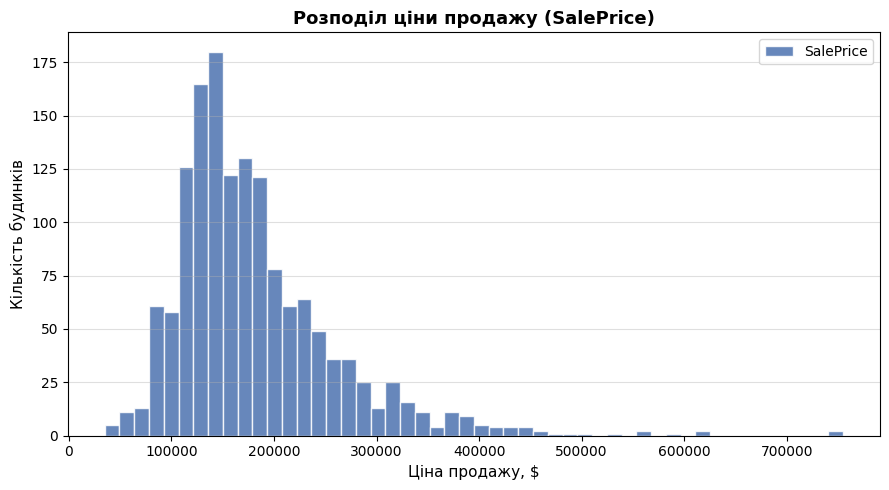

In [2]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(df_clean["Price"], bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.set_title("Розподіл ціни продажу (SalePrice)", fontsize=13, fontweight="bold")
ax.set_xlabel("Ціна продажу, $", fontsize=11)
ax.set_ylabel("Кількість будинків", fontsize=11)
ax.legend(["SalePrice"], loc="upper right")
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()


### Графік 2 — Точкова діаграма (scatter): ціна vs житлова площа

**Обґрунтування:** Scatter plot підходить для дослідження взаємозв'язку між двома числовими змінними. Хотіли перевірити, чи справді більша площа = вища ціна.

**Спостереження:** Є чітка залежність — чим більша площа, тим дорожчий будинок. Помітили також, що зелені крапки (висока якість) майже завжди вгорі — тобто якість важлива навіть при однаковій площі. Є кілька дивних точок праворуч внизу — великі будинки за дуже низькою ціною, але їх небагато.


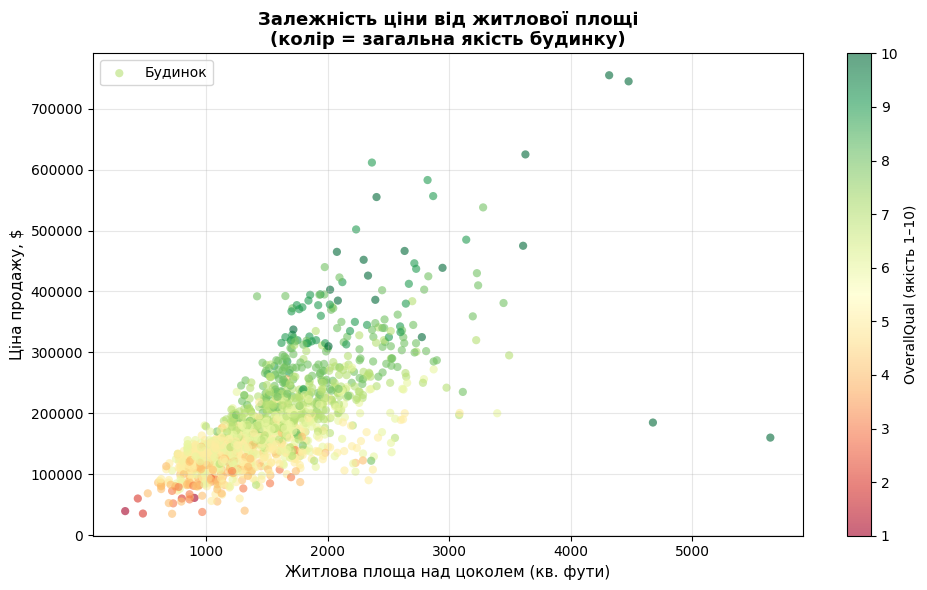

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df_clean["LivingAreaAboveGround"],
    df_clean["Price"],
    c=df_clean["OverallQual"],
    cmap="RdYlGn",
    alpha=0.6,
    s=35,
    edgecolors="none"
)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("OverallQual (якість 1–10)", fontsize=10)

ax.set_title("Залежність ціни від житлової площі\n(колір = загальна якість будинку)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Житлова площа над цоколем (кв. фути)", fontsize=11)
ax.set_ylabel("Ціна продажу, $", fontsize=11)
ax.legend(["Будинок"], loc="upper left")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


### Графік 3 — Стовпчикова діаграма (bar): середня ціна по районах

**Обґрунтування:** Стовпчикова діаграма дозволяє порівняти середні значення числової ознаки
по групах (категоріях). Нас цікавить, як район впливає на ціну будинку.

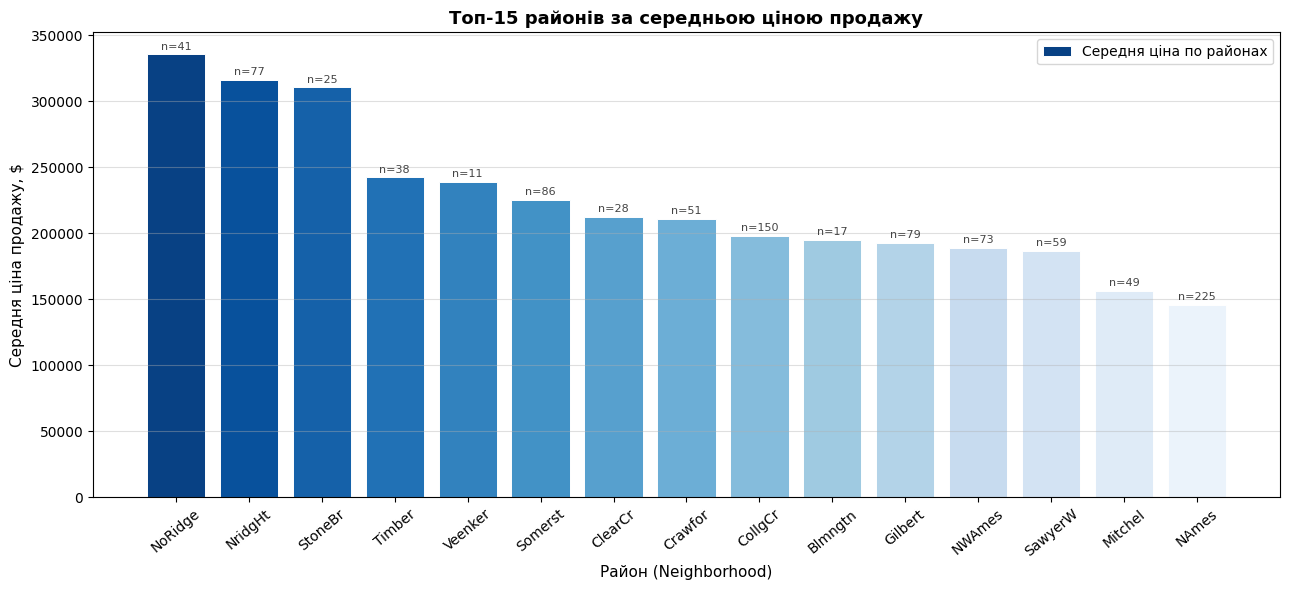

Спостереження: Ціни суттєво варіюються залежно від району.
NoRidge, NridgHt та StoneBr — найдорожчі (середня ~$300K+),
що більш ніж удвічі перевищує ціни в дешевших районах.


In [4]:
neighborhood_price = (
    df_clean.groupby("Neighborhood")["Price"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette("Blues_r", len(neighborhood_price))
bars = ax.bar(neighborhood_price.index, neighborhood_price["mean"],
              color=colors, edgecolor="white", linewidth=0.7)

# Підписи кількості будинків
for bar, (_, row) in zip(bars, neighborhood_price.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f"n={int(row['count'])}", ha="center", va="bottom", fontsize=8, color="#444")

ax.set_title("Топ-15 районів за середньою ціною продажу", fontsize=13, fontweight="bold")
ax.set_xlabel("Район (Neighborhood)", fontsize=11)
ax.set_ylabel("Середня ціна продажу, $", fontsize=11)
ax.legend(["Середня ціна по районах"])
ax.tick_params(axis="x", rotation=40)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()
print("Спостереження: Ціни суттєво варіюються залежно від району.")
print("NoRidge, NridgHt та StoneBr — найдорожчі (середня ~$300K+),")
print("що більш ніж удвічі перевищує ціни в дешевших районах.")


### Графік 4 — Горизонтальна стовпчикова діаграма (hbar): середня ціна по роках продажу

**Обґрунтування:** Горизонтальний bar зручно використовувати, коли категорій небагато і хочеться наочно порівняти значення між собою — підписи років розташовуються вздовж осі Y, а довжина стовпця одразу показує величину середньої ціни. Хотіли подивитись, як змінювалась середня ціна будинків з 2006 по 2010 рік.

**Спостереження:** Середня ціна була найвищою у 2007 році, у 2008 знизилась приблизно на 5% і трималась на цьому рівні у 2009–2010 — імовірно через фінансову кризу, хоча спад не такий великий, як можна було очікувати.


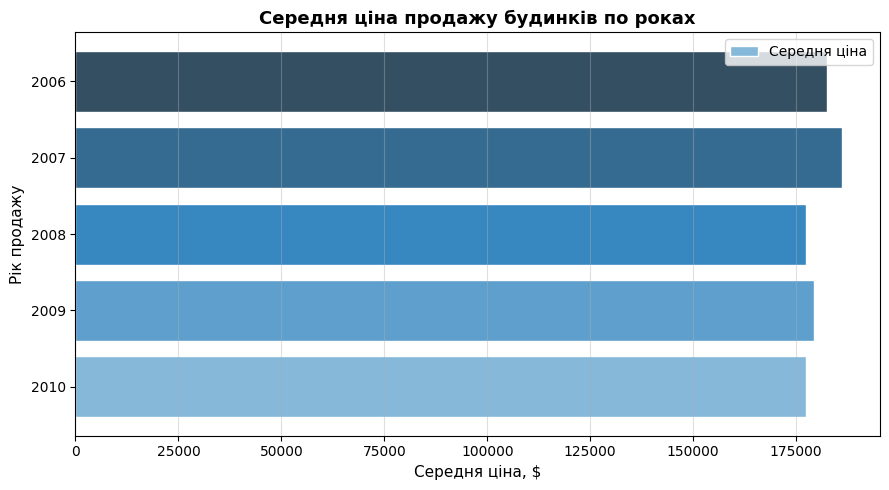

Спостереження: середня ціна найвища у 2007 році, потім невелике зниження у 2008–2010,
ймовірно пов'язане з наслідками фінансової кризи 2008 року.


In [5]:
price_by_year = df_clean.groupby("YrSold")["Price"].mean().sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors_yr = sns.color_palette("Blues_d", len(price_by_year))
ax.barh(price_by_year.index.astype(str), price_by_year.values,
        color=colors_yr, edgecolor="white")

ax.set_title("Середня ціна продажу будинків по роках", fontsize=13, fontweight="bold")
ax.set_xlabel("Середня ціна, $", fontsize=11)
ax.set_ylabel("Рік продажу", fontsize=11)
ax.legend(["Середня ціна"])
ax.grid(axis="x", alpha=0.4)

plt.tight_layout()
plt.show()
print("Спостереження: середня ціна найвища у 2007 році, потім невелике зниження у 2008–2010,")
print("ймовірно пов'язане з наслідками фінансової кризи 2008 року.")


### Графік 5 — Коробкова діаграма (boxplot): ціна за рівнем якості

**Обґрунтування:** Boxplot ідеально показує розподіл, медіану, квартилі та викиди одночасно.
Порівнюємо ціни для різних рівнів OverallQual, щоб побачити, як якість будівництва впливає на вартість.

/var/folders/ml/x1vf11ss7mxcbd6qm5wbmgjm0000gn/T/ipykernel_21143/1172926572.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="OverallQual", y="Price",


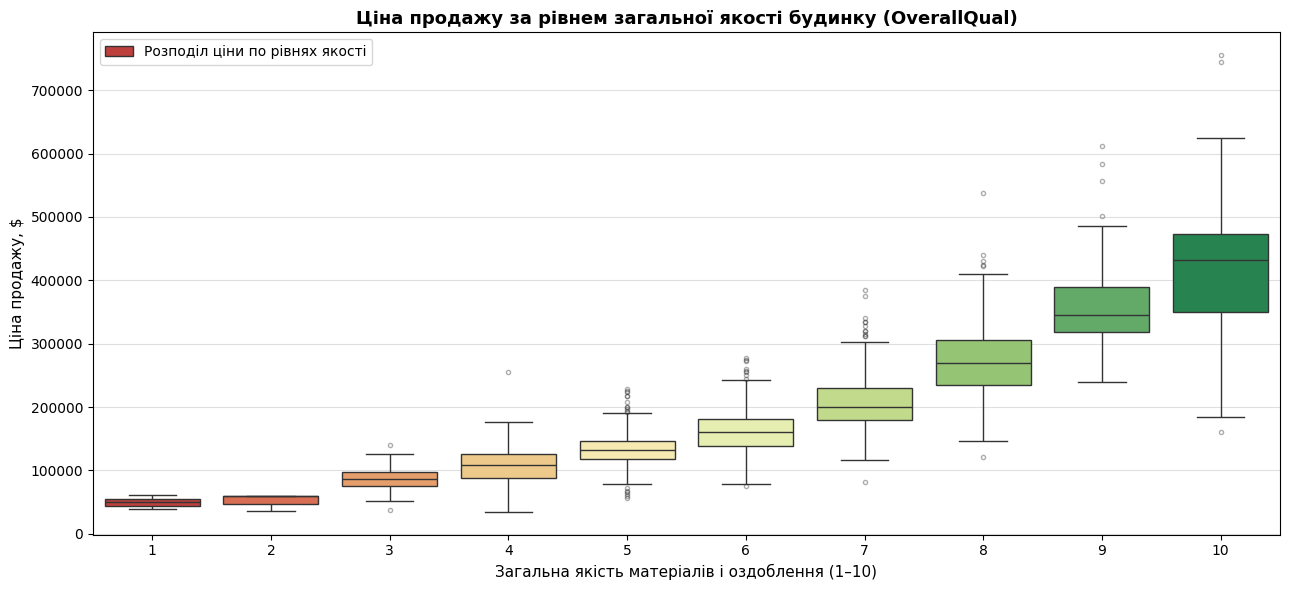

Спостереження: Зі збільшенням якості від 1 до 10 медіанна ціна монотонно зростає.
Для будинків якості 10 медіана перевищує $400K, тоді як для якості 4 — близько $108K.
Розкид (IQR) теж збільшується з якістю — дорогі будинки мають ширший цінових діапазон.


In [6]:
fig, ax = plt.subplots(figsize=(13, 6))
qual_order = sorted(df_clean["OverallQual"].unique())
palette = sns.color_palette("RdYlGn", len(qual_order))

sns.boxplot(data=df_clean, x="OverallQual", y="Price",
            order=qual_order, palette=palette, ax=ax,
            flierprops=dict(marker="o", markersize=3, alpha=0.4))

ax.set_title("Ціна продажу за рівнем загальної якості будинку (OverallQual)", fontsize=13, fontweight="bold")
ax.set_xlabel("Загальна якість матеріалів і оздоблення (1–10)", fontsize=11)
ax.set_ylabel("Ціна продажу, $", fontsize=11)
ax.legend(["Розподіл ціни по рівнях якості"])
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()
print("Спостереження: Зі збільшенням якості від 1 до 10 медіанна ціна монотонно зростає.")
print("Для будинків якості 10 медіана перевищує $400K, тоді як для якості 4 — близько $108K.")
print("Розкид (IQR) теж збільшується з якістю — дорогі будинки мають ширший цінових діапазон.")


### Графік 6 — Скрипкова діаграма (violinplot): ціна за кількістю машиномісць у гаражі

**Обґрунтування:** Violinplot поєднує boxplot і KDE — показує форму розподілу, а не лише статистики.
Цікаво порівняти, як місткість гаража впливає на вартість будинку.

/var/folders/ml/x1vf11ss7mxcbd6qm5wbmgjm0000gn/T/ipykernel_21143/2660883068.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=garage_data, x="GarageCars", y="Price",


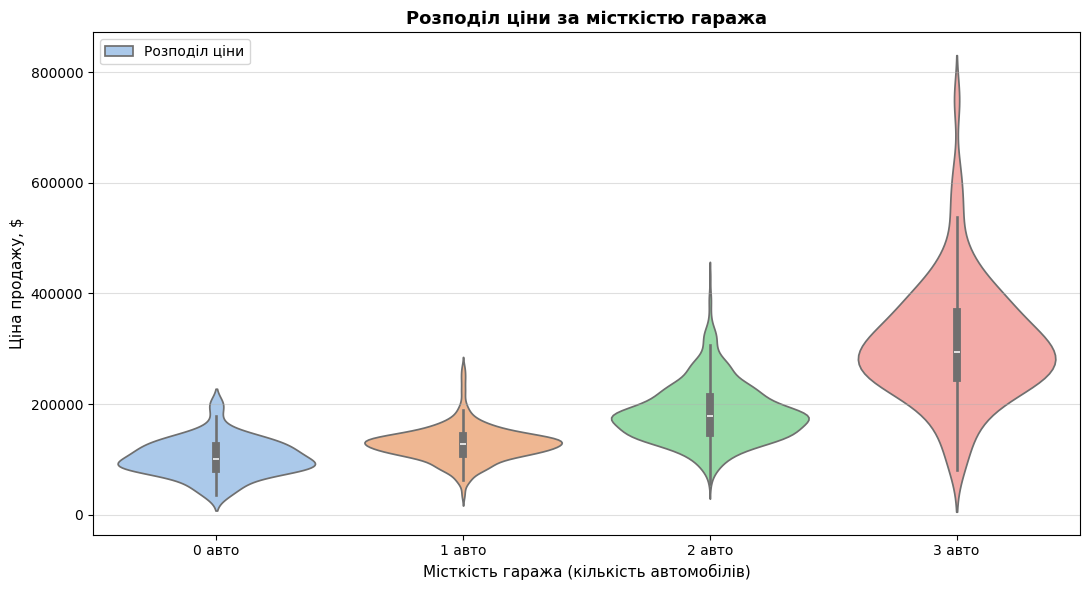

Спостереження: Будинки без гаража (0 авто) мають найнижчу і найбільш рівномірну ціну.
Будинки з гаражем на 2 авто — найчисленніша група з найширшим розподілом.
Гараж на 3 авто суттєво корелює з вищою ціною, але таких будинків набагато менше.


In [7]:
garage_data = df_clean[df_clean["GarageCars"] <= 3].copy()
garage_data["GarageCars"] = garage_data["GarageCars"].astype(str) + " авто"

fig, ax = plt.subplots(figsize=(11, 6))
order_v = [f"{i} авто" for i in [0,1,2,3]]
sns.violinplot(data=garage_data, x="GarageCars", y="Price",
               order=order_v, palette="pastel", inner="box", ax=ax)

ax.set_title("Розподіл ціни за місткістю гаража", fontsize=13, fontweight="bold")
ax.set_xlabel("Місткість гаража (кількість автомобілів)", fontsize=11)
ax.set_ylabel("Ціна продажу, $", fontsize=11)
ax.legend(["Розподіл ціни"])
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()
print("Спостереження: Будинки без гаража (0 авто) мають найнижчу і найбільш рівномірну ціну.")
print("Будинки з гаражем на 2 авто — найчисленніша група з найширшим розподілом.")
print("Гараж на 3 авто суттєво корелює з вищою ціною, але таких будинків набагато менше.")


### Графік 7 — Кругова діаграма (pie chart): структура за типом будівлі

**Обґрунтування:** Pie chart підходить для показу часткових пропорцій у межах цілого.
Хочемо побачити, який тип забудови (одиночний будинок, таунхаус, дуплекс) переважає в датасеті.

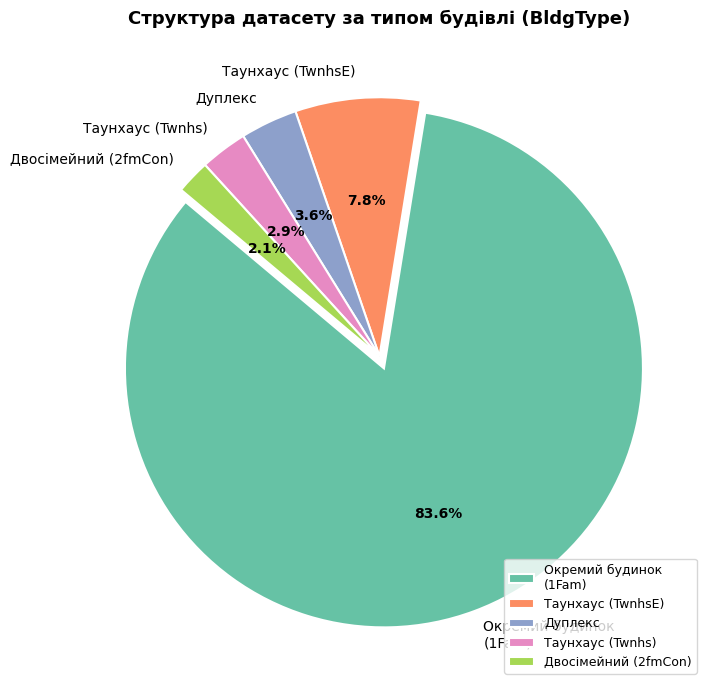

Спостереження: Переважна більшість (83.6%) — окремі одиночні будинки (1Fam).
Таунхауси та дуплекси складають менше 17%, що відображає типову структуру
приміського ринку нерухомості США.


In [8]:
bldg_counts = df_clean["BldgType"].value_counts()
bldg_labels = {
    "1Fam": "Окремий будинок\n(1Fam)",
    "TwnhsE": "Таунхаус (TwnhsE)",
    "Duplex": "Дуплекс",
    "Twnhs": "Таунхаус (Twnhs)",
    "2fmCon": "Двосімейний (2fmCon)"
}
labels = [bldg_labels.get(k, k) for k in bldg_counts.index]

fig, ax = plt.subplots(figsize=(9, 7))
explode = [0.05] + [0]*( len(bldg_counts)-1)
wedges, texts, autotexts = ax.pie(
    bldg_counts.values,
    labels=labels,
    autopct="%1.1f%%",
    explode=explode,
    colors=sns.color_palette("Set2"),
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight("bold")

ax.set_title("Структура датасету за типом будівлі (BldgType)", fontsize=13, fontweight="bold")
ax.legend(wedges, labels, loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()
print("Спостереження: Переважна більшість (83.6%) — окремі одиночні будинки (1Fam).")
print("Таунхауси та дуплекси складають менше 17%, що відображає типову структуру")
print("приміського ринку нерухомості США.")


### Графік 8 — Графік щільності (KDE): розподіл площі по типах продажу

**Обґрунтування:** KDE (Kernel Density Estimation) — неперервна альтернатива гістограмі.
Порівнюємо розподіл житлової площі для різних умов продажу (SaleCondition),
щоб визначити, чи впливають умови на розмір проданих будинків.

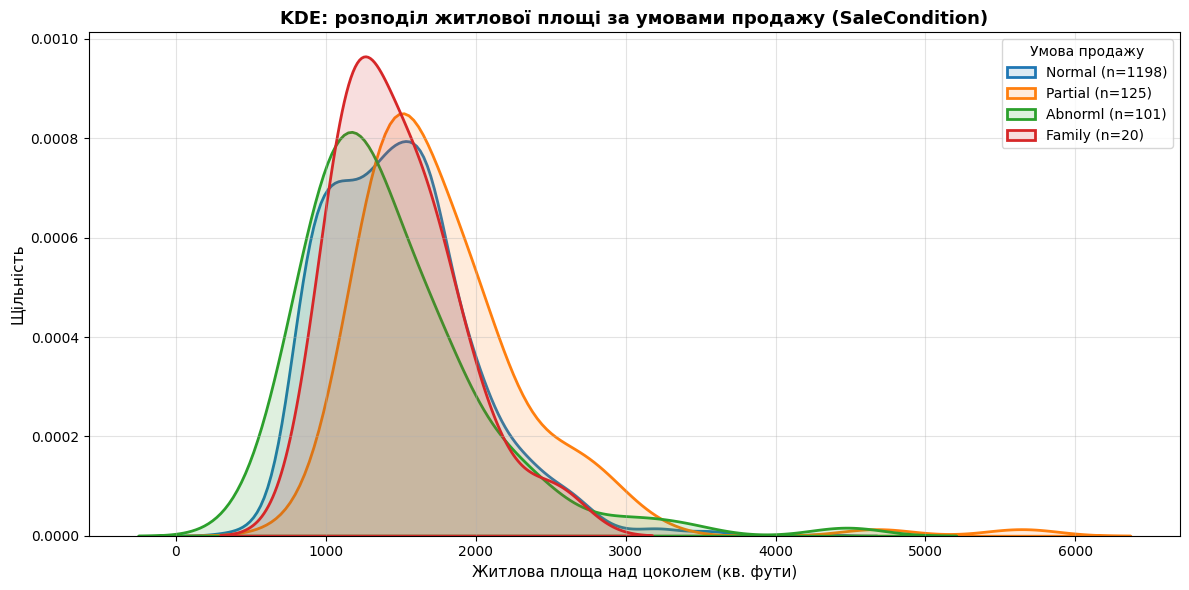

Спостереження: Нормальні (Normal) продажі мають найширший розподіл площі.
Часткові продажі (Partial) — переважно нові будинки — мають вищу концентрацію
у діапазоні 1200–2000 кв. футів. Abnormal продажі розподілені більш рівномірно.


In [9]:
fig, ax = plt.subplots(figsize=(12, 6))

top_conditions = df_clean["SaleCondition"].value_counts().head(4).index
palette_kde = sns.color_palette("tab10", len(top_conditions))

for cond, color in zip(top_conditions, palette_kde):
    subset = df_clean[df_clean["SaleCondition"] == cond]["LivingAreaAboveGround"]
    sns.kdeplot(subset, ax=ax, label=f"{cond} (n={len(subset)})",
                color=color, linewidth=2, fill=True, alpha=0.15)

ax.set_title("KDE: розподіл житлової площі за умовами продажу (SaleCondition)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Житлова площа над цоколем (кв. фути)", fontsize=11)
ax.set_ylabel("Щільність", fontsize=11)
ax.legend(title="Умова продажу", fontsize=10)
ax.grid(alpha=0.35)

plt.tight_layout()
plt.show()
print("Спостереження: Нормальні (Normal) продажі мають найширший розподіл площі.")
print("Часткові продажі (Partial) — переважно нові будинки — мають вищу концентрацію")
print("у діапазоні 1200–2000 кв. футів. Abnormal продажі розподілені більш рівномірно.")


### Графік 9 — Теплова карта кореляцій (heatmap): ключові числові ознаки

**Обґрунтування:** Heatmap дозволяє побачити всі парні кореляції між кількома змінними одночасно.
Вибираємо найважливіші числові ознаки, щоб знайти мультиколінеарність та сильні зв'язки.

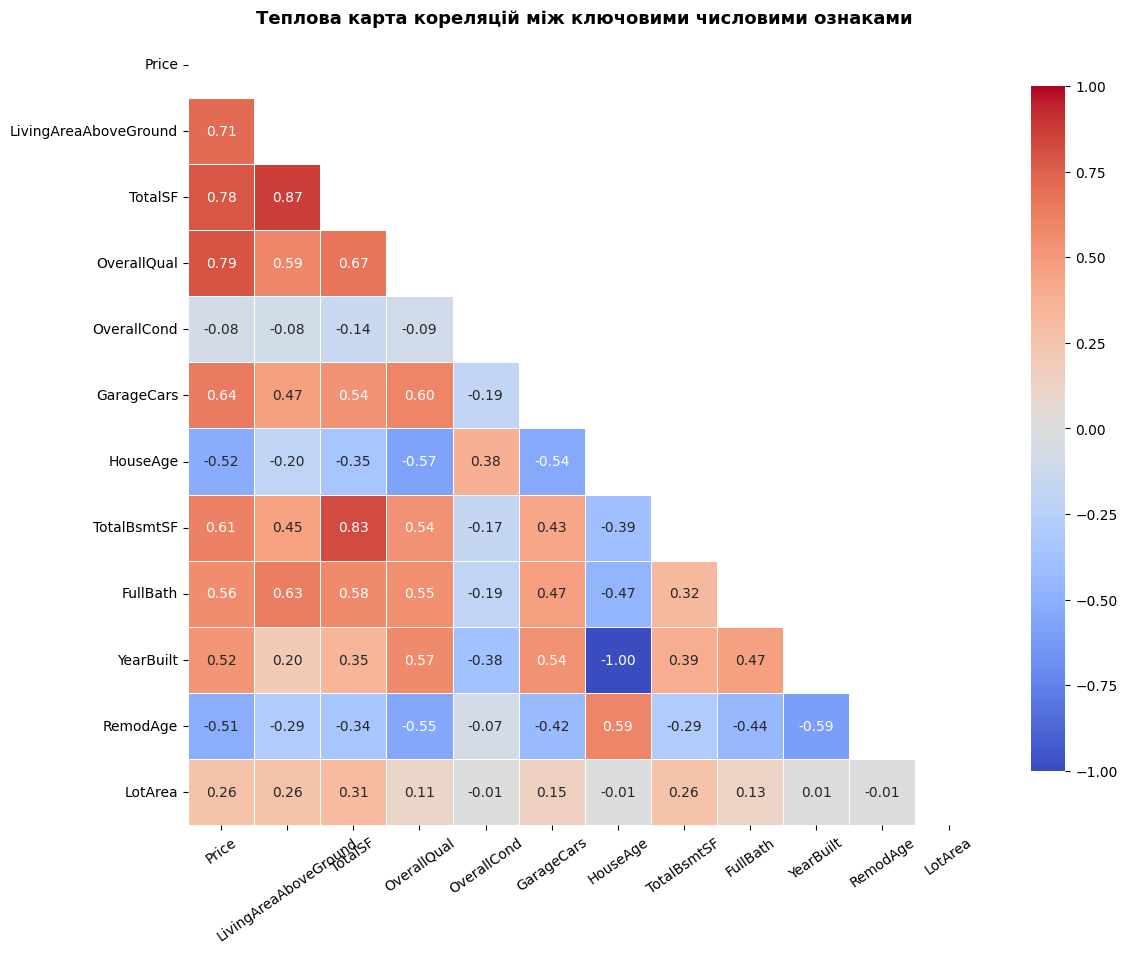

Спостереження: Найсильніша кореляція з Price — у TotalSF (0.78), OverallQual (0.79),
LivingAreaAboveGround (0.71). Зверніть увагу на мультиколінеарність:
TotalSF та LivingAreaAboveGround корелюють між собою (0.83) — це важливо для моделювання.


In [10]:
key_cols = ["Price", "LivingAreaAboveGround", "TotalSF", "OverallQual", "OverallCond",
            "GarageCars", "HouseAge", "TotalBsmtSF", "FullBath", "YearBuilt", "RemodAge", "LotArea"]

corr_df = df_clean[key_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(corr_df, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            ax=ax, square=True, cbar_kws={"shrink": 0.8})

ax.set_title("Теплова карта кореляцій між ключовими числовими ознаками",
             fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()
print("Спостереження: Найсильніша кореляція з Price — у TotalSF (0.78), OverallQual (0.79),")
print("LivingAreaAboveGround (0.71). Зверніть увагу на мультиколінеарність:")
print("TotalSF та LivingAreaAboveGround корелюють між собою (0.83) — це важливо для моделювання.")


### Графік 10 — Лінійний графік (line): динаміка середньої ціни по роках продажу

**Обґрунтування:** Лінійний графік найкраще показує тренди в часі. Цікаво було подивитись, чи видно вплив фінансової кризи 2008 року на ціни.

**Спостереження:** Після піку у 2007 році ціни трохи впали (середня — вже у 2008, медіанна досягла мінімуму у 2010) — мабуть через кризу, хоча спад не такий великий як ми очікували. Середня і медіанна ціна поводяться схоже, що говорить про відсутність різких зсувів у структурі ринку.


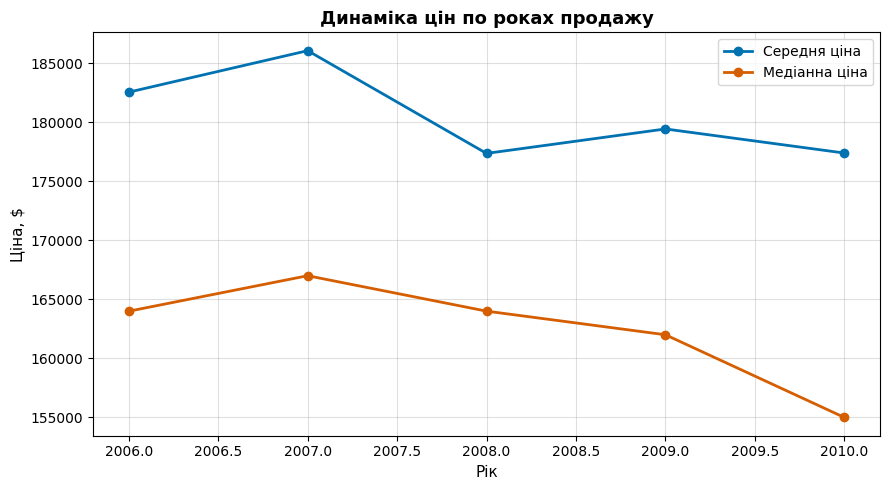

In [11]:
price_by_year = df_clean.groupby("YrSold")["Price"].agg(["mean", "median"]).reset_index()

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(price_by_year["YrSold"], price_by_year["mean"],
        marker="o", color="#0072B2", linewidth=2, label="Середня ціна")
ax.plot(price_by_year["YrSold"], price_by_year["median"],
        marker="o", color="#D55E00", linewidth=2, label="Медіанна ціна")

ax.set_title("Динаміка цін по роках продажу", fontsize=13, fontweight="bold")
ax.set_xlabel("Рік", fontsize=11)
ax.set_ylabel("Ціна, $", fontsize=11)
ax.legend()
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()


### Графік 11 — Коробкова діаграма (boxplot): ціна за кількістю спалень

**Обґрунтування:** Другий boxplot у роботі, але для іншої категоріальної змінної — кількості спалень (BedroomAbvGr). Boxplot добре показує медіану, розкид і викиди для кожної групи, тож зручно перевірити, чи більша кількість кімнат завжди означає вищу ціну.

**Спостереження:** Найвища медіанна ціна спостерігається у будинків із 4 спальнями (близько $194K), дещо нижча — у будинків із 3 спальнями. Будинки з 5–6 спальнями коштують навіть дешевше, ніж із 3–4 — отже кількість кімнат сама по собі не є головним фактором ціни, важливіші площа, якість і район (групи з 0, 5 і 6 спальнями також дуже малочисельні, тож їхні медіани менш надійні).


/var/folders/ml/x1vf11ss7mxcbd6qm5wbmgjm0000gn/T/ipykernel_21143/4130168253.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bedroom_data, x="BedroomAbvGr", y="Price",


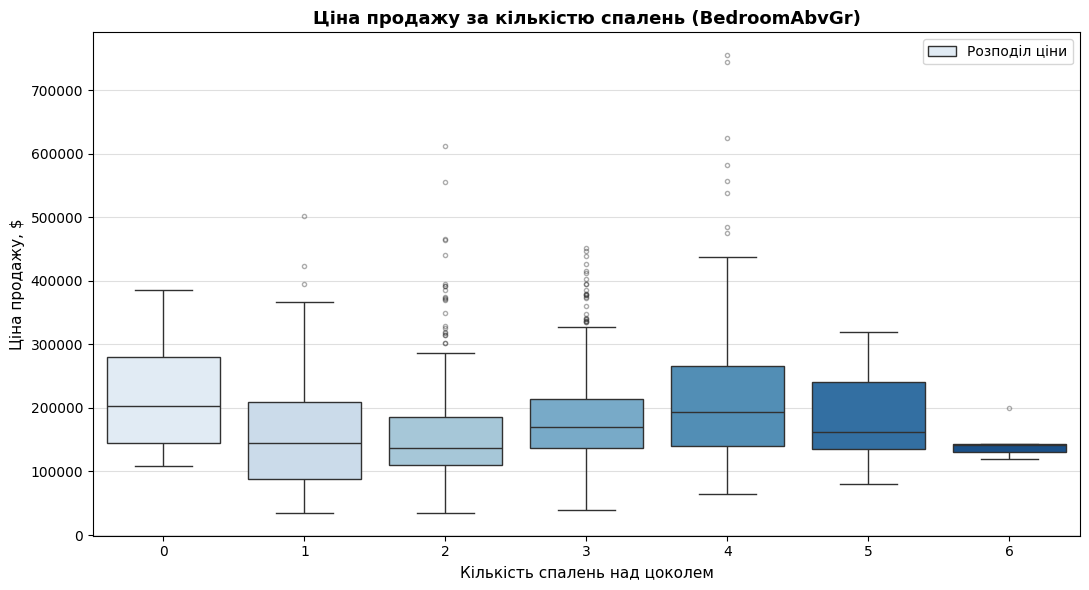

Спостереження: медіанна ціна найвища у будинків із 4 спальнями (~$194K).
Будинки з 5-6 спальнями часто дешевші, ніж з 3-4 - отже кількість кімнат
сама по собі не визначає ціну, важливіші площа, якість і район.


In [12]:
bedroom_data = df_clean[df_clean["BedroomAbvGr"] <= 6].copy()

fig, ax = plt.subplots(figsize=(11, 6))
order_br = sorted(bedroom_data["BedroomAbvGr"].unique())
palette_br = sns.color_palette("Blues", len(order_br))

sns.boxplot(data=bedroom_data, x="BedroomAbvGr", y="Price",
            order=order_br, palette=palette_br, ax=ax,
            flierprops=dict(marker="o", markersize=3, alpha=0.4))

ax.set_title("Ціна продажу за кількістю спалень (BedroomAbvGr)", fontsize=13, fontweight="bold")
ax.set_xlabel("Кількість спалень над цоколем", fontsize=11)
ax.set_ylabel("Ціна продажу, $", fontsize=11)
ax.legend(["Розподіл ціни"])
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()
print("Спостереження: медіанна ціна найвища у будинків із 4 спальнями (~$194K).")
print("Будинки з 5-6 спальнями часто дешевші, ніж з 3-4 - отже кількість кімнат")
print("сама по собі не визначає ціну, важливіші площа, якість і район.")


### Графік 12 — Складена стовпчикова діаграма (stacked bar): якість за типом будівлі

**Обґрунтування:** Складений стовпчик показує одночасно абсолютні значення та структуру всередині групи.
Порівнюємо розподіл якості (OverallQual) для різних типів будівлі (BldgType).

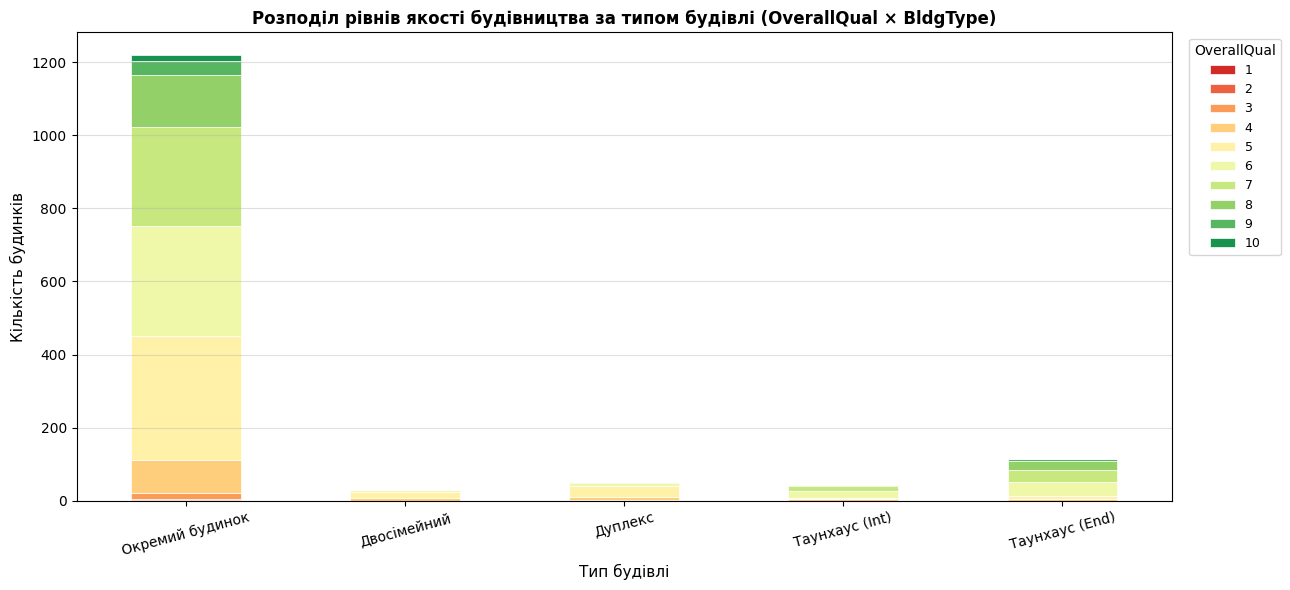

Спостереження: Окремі будинки (1Fam) мають найширший діапазон якості — від 1 до 10.
Таунхауси (TwnhsE) тяжіють до середньої та вищої якості (6–8).
Дуплекси зосереджені переважно у нижньому-середньому сегменті (4–6).


In [13]:
qual_bldg = df_clean.groupby(["BldgType", "OverallQual"]).size().unstack(fill_value=0)
bldg_labels_full = {
    "1Fam": "Окремий будинок",
    "TwnhsE": "Таунхаус (End)",
    "Duplex": "Дуплекс",
    "Twnhs": "Таунхаус (Int)",
    "2fmCon": "Двосімейний"
}
qual_bldg.index = [bldg_labels_full.get(i, i) for i in qual_bldg.index]

fig, ax = plt.subplots(figsize=(13, 6))
colors_stacked = sns.color_palette("RdYlGn", qual_bldg.shape[1])
qual_bldg.plot(kind="bar", stacked=True, ax=ax, color=colors_stacked, edgecolor="white", linewidth=0.5)

ax.set_title("Розподіл рівнів якості будівництва за типом будівлі (OverallQual × BldgType)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Тип будівлі", fontsize=11)
ax.set_ylabel("Кількість будинків", fontsize=11)
ax.legend(title="OverallQual", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
ax.tick_params(axis="x", rotation=15)
ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.show()
print("Спостереження: Окремі будинки (1Fam) мають найширший діапазон якості — від 1 до 10.")
print("Таунхауси (TwnhsE) тяжіють до середньої та вищої якості (6–8).")
print("Дуплекси зосереджені переважно у нижньому-середньому сегменті (4–6).")


## 3. Аналіз та інтерпретація

Після побудови 12 графіків 8 різних типів (гістограма, scatter, bar, hbar, boxplot, violinplot, pie chart, KDE, heatmap, line, stacked bar) можу зробити такі узагальнені висновки про датасет House Prices.

### Основні тенденції в даних

Більшість будинків у датасеті коштує від $100K до $250K — розподіл ціни (Графік 1) сильно скошений вправо, з невеликою кількістю дуже дорогих об'єктів понад $400K. Найбільший вплив на ціну мають загальна якість будівництва (OverallQual), загальна площа (TotalSF) і житлова площа над цоколем (LivingAreaAboveGround) — це підтверджують Графік 2, Графік 5 і теплова карта кореляцій (Графік 9). Район (Neighborhood) також є потужним фактором: у NoRidge і NridgHt будинки коштують у середньому приблизно втричі більше, ніж у найдешевших районах (Графік 3). Окремі будинки (1Fam) переважають у структурі датасету — майже 84% (Графік 7).

### Виявлені залежності

- **Площа і ціна** — чим більша житлова площа, тим вища ціна (Графік 2), і ця залежність посилюється якістю будівництва (кольорове кодування на тому ж графіку).
- **Якість і ціна** — зв'язок майже монотонний і дуже сильний (Графік 5): для якості 10 медіанна ціна перевищує $400K, для якості 4 — близько $108K. Розкид цін також зростає з якістю.
- **Гараж і ціна** — наявність і місткість гаража помітно пов'язані з ціною (Графік 6): будинки без гаража — найдешевші, а гараж на 3 авто майже завжди означає дорогий будинок.
- **Рік продажу і ціна** — динаміка по роках (Графік 4 і Графік 10) показує невелике зниження цін після піку 2007 року: середня ціна знизилась у 2008, а медіанна досягла мінімуму у 2010, що узгоджується з періодом фінансової кризи 2008 року.

### Несподівані закономірності та аномалії

Найнесподіванішим виявився результат Графіка 11: кількість спалень (BedroomAbvGr) не пов'язана з ціною прямолінійно — будинки з 5–6 спальнями нерідко коштують дешевше, ніж будинки з 3–4 спальнями. Це суперечить інтуїтивному припущенню «більше кімнат — вища ціна» і свідчить про те, що площа, якість і район важливіші за саму кількість приміщень. Також помітно (Графік 9), що OverallCond (поточний стан будинку) майже не корелює з ціною, тоді як OverallQual (якість матеріалів і оздоблення на момент будівництва) — дуже сильно: покупці орієнтуються більше на клас будівництва, ніж на поточний стан об'єкта. Крім цього, TotalSF і LivingAreaAboveGround виявились сильно взаємопов'язаними між собою (Графік 9), що логічно, оскільки одна ознака частково входить до складу іншої, і про це варто пам'ятати при подальшому моделюванні (мультиколінеарність).

### Найінформативніші графіки

Найкориснішими виявилися:
- **Теплова карта кореляцій (Графік 9)** — одразу показує всі парні зв'язки між числовими ознаками і допомагає швидко визначити найважливіші предиктори ціни.
- **Scatter «ціна vs житлова площа» (Графік 2)** — наочно демонструє залежність і додатково кодує якість кольором, що дає двовимірну картину одразу.
- **Boxplot «ціна за якістю» (Графік 5)** — чітко й монотонно показує зростання ціни з якістю та зміну розкиду значень.

### Ідеї для подальшого аналізу

- Дослідити, чи змінювалась популярність (середня ціна) окремих районів у часі — тобто побудувати динаміку цін не загалом, а в розрізі Neighborhood.
- Побудувати просту лінійну регресію ціни від площі (TotalSF, LivingAreaAboveGround) і оцінити, наскільки добре вона узгоджується з реальними цінами.
- Порівняти окремо новобудови (низький HouseAge) і старі будинки — можливо, фактори, що впливають на ціну, для них різні.
- Розібратись детальніше з аномальними точками на Графіку 2 (великі будинки за невисоку ціну) — перевірити, чи це пов'язано з типом продажу (SaleCondition) або станом будинку.
